**Customer Churn Prediction**

---


# ***Problem Statement***

The goal of this project is to predict customer churn using machine learning techniques on telecom customer data. By identifying customers who are likely to leave the company, businesses can implement targeted retention strategies to improve customer satisfaction and reduce revenue loss.

In [460]:
"""libraries"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import joblib

**Data Loading**

In [461]:
df=pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [462]:
print("Shape :\n",df.shape)
print("\nData Types:\n", df.dtypes)
print("\n",df.info())
print("\n",df.describe())

Shape :
 (7043, 21)

Data Types:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner          

**Data Cleaning**

In [463]:
"""handling missing values"""
print("\n Missing values:\n",df.isnull().sum())
print("\n duplicates:\n",df.duplicated().sum())



 Missing values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

 duplicates:
 0


In [464]:
print(df.columns)
df.drop(columns=["customerID"],inplace=True)


Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


**Data Preprocessing**

In [465]:
le=LabelEncoder()
for i in df.columns:
  if df[i].dtype=="object":
    df[i]=le.fit_transform(df[i])
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,2505,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1466,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,157,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1400,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,925,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,2,0,2,0,2,2,2,2,1,1,3,84.80,1597,0
7039,0,0,1,1,72,1,2,1,0,2,2,0,2,2,1,1,1,103.20,5698,0
7040,0,0,1,1,11,0,1,0,2,0,0,0,0,0,0,1,2,29.60,2994,0
7041,1,1,1,0,4,1,2,1,0,0,0,0,0,0,0,1,3,74.40,2660,1


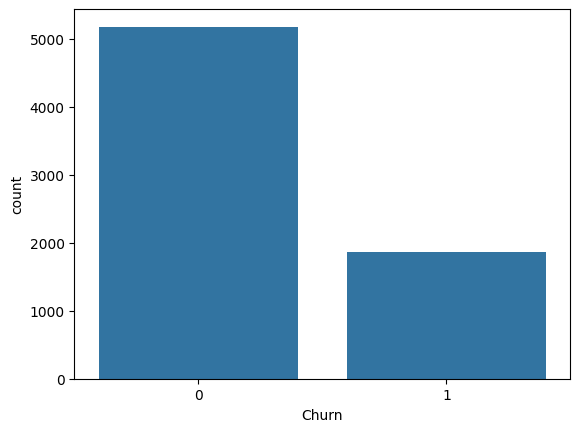

In [466]:
sns.countplot(x='Churn',data=df)
plt.show()

In [467]:
"""Identifying target and feature variables"""
x=df.drop(columns=["Churn"])
y=df["Churn"]

**Train-Test Split**

In [468]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=True)

**Feature Scaling**

In [469]:
scaler=MinMaxScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

**Model Building**

**Logistic Regression**

Train Accuracy: 0.8028044018459354
Test Accuracy:  0.8090844570617459
              precision    recall  f1-score   support

           0       0.86      0.89      0.88      1061
           1       0.63      0.57      0.59       348

    accuracy                           0.81      1409
   macro avg       0.74      0.73      0.73      1409
weighted avg       0.80      0.81      0.81      1409

[[943 118]
 [151 197]]


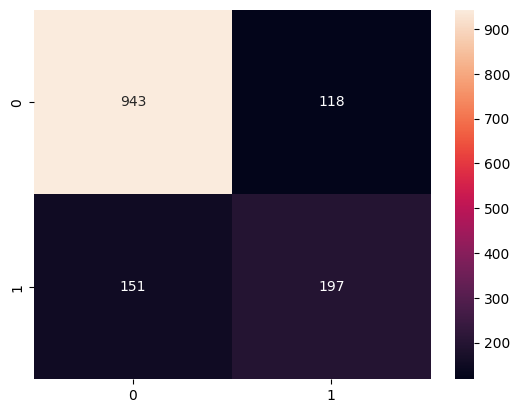

In [470]:
#before smote
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
model=LogisticRegression(max_iter=5000)
model.fit(x_train,y_train)
yp1=model.predict(x_train)
train_acc=accuracy_score(y_train,yp1)
print("Train Accuracy:",train_acc)
yp2=model.predict(x_test)
test_acc=accuracy_score(y_test,yp2)
print("Test Accuracy: ",test_acc)
print(classification_report(y_test,yp2))
print(confusion_matrix(y_test,yp2))
cm=confusion_matrix(y_test,yp2)
sns.heatmap(cm,annot=True,fmt='d')
plt.show()




**Conclusion:**
Logistic Regression achieved an accuracy of 80.9% with an F1-score of 0.59. The model performed well in identifying non-churn customers but showed lower recall (57%) for churn customers, indicating that a significant number of actual churn cases were missed. This suggests that class imbalance may be affecting model performance and motivates the use of SMOTE for improving churn detection.

In [471]:
"""Balancing train data"""
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=42)
x_train_sm,y_train_sm=smote.fit_resample(x_train,y_train)

**Logistic Regression + SMOTE**

Train Accuracy: 0.7654996353026987
Test Accuracy:  0.7537260468417317
              precision    recall  f1-score   support

           0       0.93      0.73      0.82      1061
           1       0.50      0.82      0.62       348

    accuracy                           0.75      1409
   macro avg       0.71      0.78      0.72      1409
weighted avg       0.82      0.75      0.77      1409

[[777 284]
 [ 63 285]]


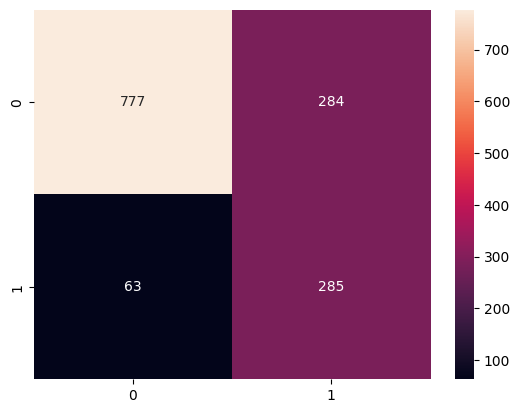

In [472]:
#After smote
model=LogisticRegression(max_iter=5000)
model.fit(x_train_sm,y_train_sm)
yp1=model.predict(x_train_sm)
train_acc=accuracy_score(y_train_sm,yp1)
print("Train Accuracy:",train_acc)
yp2=model.predict(x_test)
test_acc=accuracy_score(y_test,yp2)
print("Test Accuracy: ",test_acc)
print(classification_report(y_test,yp2))
print(confusion_matrix(y_test,yp2))
cm=confusion_matrix(y_test,yp2)
sns.heatmap(cm,annot=True,fmt='d')
plt.show()




### **Conclusion**

After applying SMOTE to balance the training data, Logistic Regression achieved an accuracy of 75.4% and an F1-score of 0.62. Although the overall accuracy decreased compared to the model trained on the original dataset, the recall for churn customers improved significantly from 57% to 82%.

This improvement indicates that the model became much better at identifying customers who are likely to churn, reducing the number of missed churn cases. Therefore, SMOTE successfully addressed the class imbalance problem and improved the model's ability to detect the minority class.

**Random Forest + SMOTE**

Accuracy:  0.7885024840312278

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.84      0.86      1061
           1       0.57      0.62      0.59       348

    accuracy                           0.79      1409
   macro avg       0.72      0.73      0.73      1409
weighted avg       0.80      0.79      0.79      1409



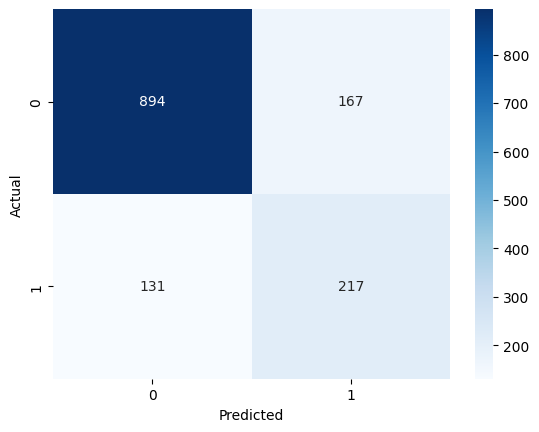

In [473]:
#random forest
from sklearn.ensemble import RandomForestClassifier
model_rf=RandomForestClassifier(n_estimators=100,random_state=42)
model_rf.fit(x_train_sm,y_train_sm)
y_pred=model_rf.predict(x_test)
RF_accuracy=accuracy_score(y_test,y_pred)
print("Accuracy: ",RF_accuracy)
print("\nClassification Report:\n",classification_report(y_test,y_pred))
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='g',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()




### **Conclusion**

Random Forest achieved an accuracy of 78.9% with an F1-score of 0.59. Compared to Logistic Regression with SMOTE, it provided a better balance between overall accuracy and churn detection performance. The model successfully identified 62% of churn customers while maintaining strong performance on non-churn customers.

The results indicate that Random Forest is effective for customer churn prediction and offers a good trade-off between accuracy and recall, making it a suitable candidate for the final model.

**XGBoost + SMOTE**

Accuracy:  0.7906316536550745

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.84      0.86      1061
           1       0.57      0.65      0.61       348

    accuracy                           0.79      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.80      0.79      0.80      1409



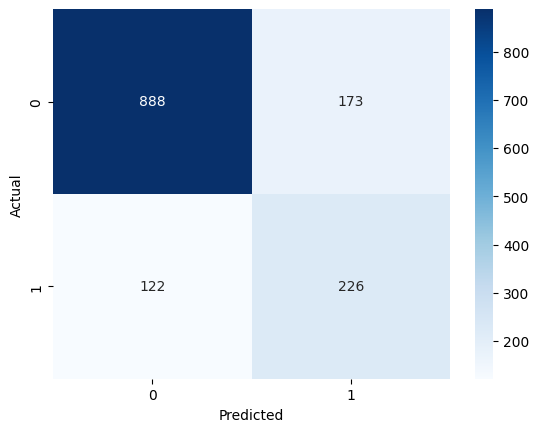

In [474]:
#XGBoost
from xgboost import XGBClassifier
model_xgb=XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss')
model_xgb.fit(x_train_sm,y_train_sm)
y_pred=model_xgb.predict(x_test)
XGB_accuracy=accuracy_score(y_test,y_pred)
print("Accuracy: ",XGB_accuracy)
print("\nClassification Report:\n",classification_report(y_test,y_pred))
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='g',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


### **Conclusion**

XGBoost achieved an accuracy of 79.1% with an F1-score of 0.61. The model demonstrated a balanced performance by maintaining good overall accuracy while improving churn detection, achieving a recall of 65% for churn customers.

Compared to Random Forest, XGBoost achieved slightly higher recall and F1-score, indicating a better ability to identify customers likely to churn. These results show that XGBoost is an effective ensemble learning technique for customer churn prediction.

**Feature Importance Analysis**

In [475]:
importance = model_xgb.feature_importances_
features = pd.DataFrame({'Feature': x.columns, 'Importance': importance})
sort=features.sort_values(by='Importance', ascending=False)
print(sort)

             Feature  Importance
14          Contract    0.401771
7    InternetService    0.108857
16     PaymentMethod    0.076278
8     OnlineSecurity    0.053805
11       TechSupport    0.041023
13   StreamingMovies    0.033066
15  PaperlessBilling    0.032814
5       PhoneService    0.029743
4             tenure    0.027739
3         Dependents    0.023010
9       OnlineBackup    0.022858
6      MultipleLines    0.022255
12       StreamingTV    0.019987
2            Partner    0.019778
0             gender    0.019111
17    MonthlyCharges    0.019075
1      SeniorCitizen    0.017768
10  DeviceProtection    0.015983
18      TotalCharges    0.015079


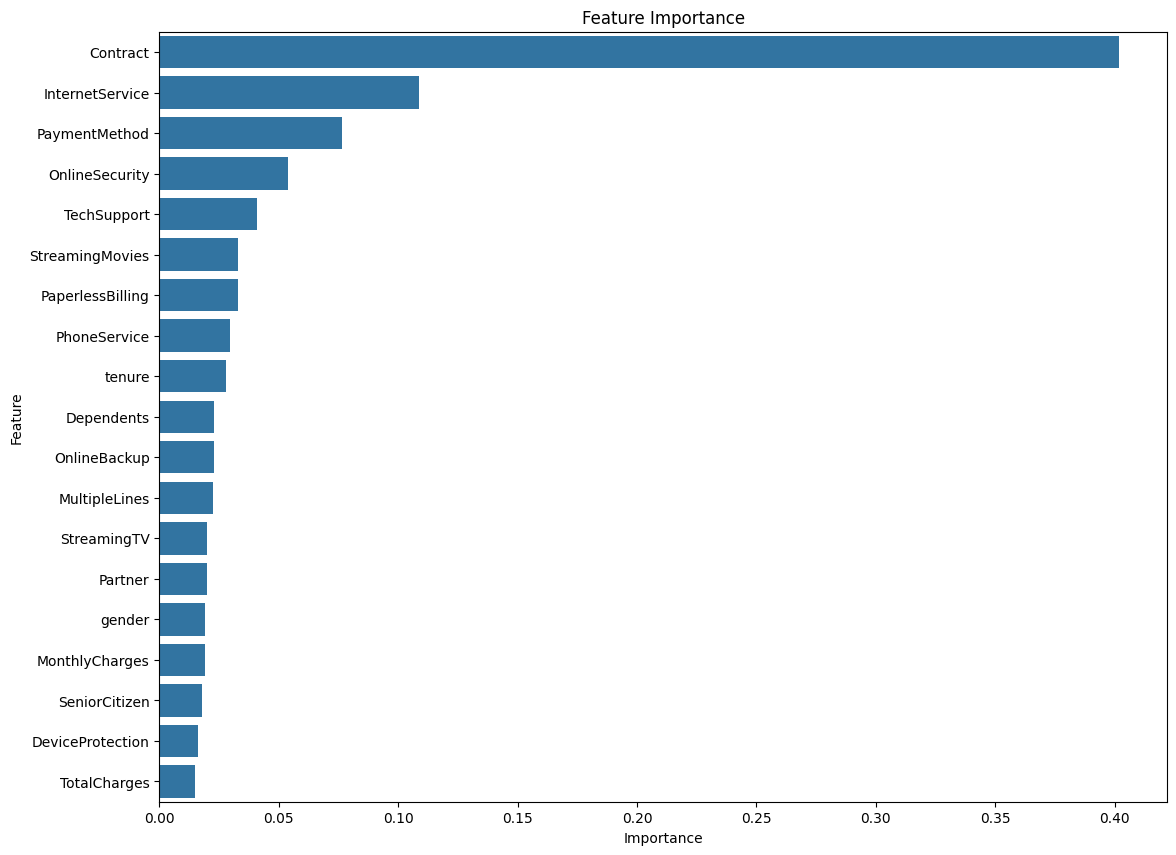

In [476]:
plt.figure(figsize=(13,10))
sns.barplot(x='Importance', y='Feature', data=sort)
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

### **Conclusion**

Feature importance analysis showed that Contract, Tenure, Monthly Charges, and Total Charges were the most important factors affecting customer churn. The results indicate that contract type, customer loyalty, and pricing-related features play a major role in customer retention. These insights can help telecom companies design targeted strategies to reduce churn and improve customer satisfaction.

**Model Comparison**

In [477]:
"""Model comparision table"""
results = pd.DataFrame({
    "Model":["Logistic Regression","Logistic + SMOTE", "Random Forest + SMOTE","XGBoost + SMOTE"],
    "Accuracy":[0.809,0.753,0.788,0.790],
    "Recall":[0.57,0.82,0.62, 0.65],
    "F1":[0.59,0.62,0.59,0.61]
})

results

,Model,Accuracy,Recall,F1
0,Logistic Regression,0.809,0.57,0.59
1,Logistic + SMOTE,0.753,0.82,0.62
2,Random Forest + SMOTE,0.788,0.62,0.59
3,XGBoost + SMOTE,0.790,0.65,0.61


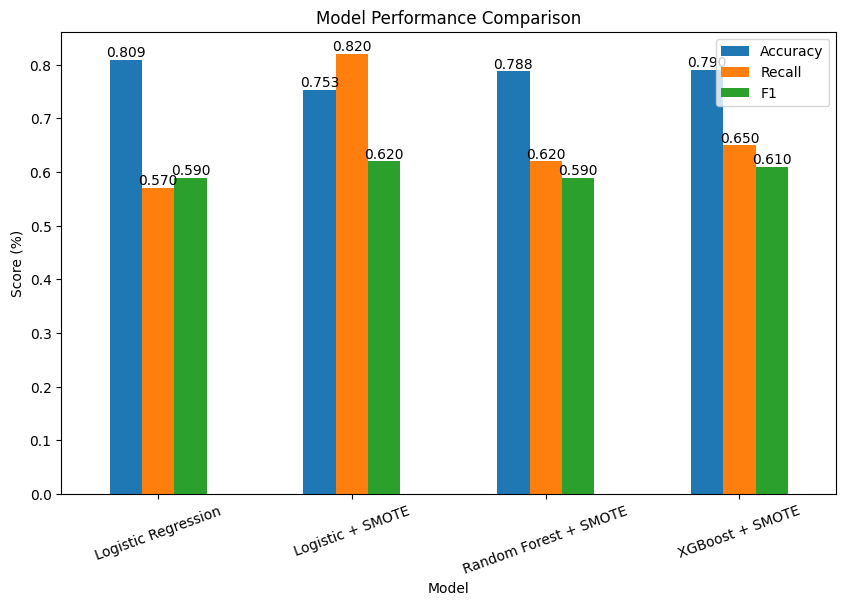

In [478]:
results = pd.DataFrame({
    "Model":["Logistic Regression","Logistic + SMOTE", "Random Forest + SMOTE","XGBoost + SMOTE"],
    "Accuracy":[0.809,0.753,0.788,0.790],
    "Recall":[0.57,0.82,0.62, 0.65],
    "F1":[0.59,0.62,0.59,0.61]
})
ax=results.set_index('Model').plot( kind='bar',figsize=(10,6))
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f')
plt.title("Model Performance Comparison")
plt.ylabel("Score (%)")
plt.xticks(rotation=20)
plt.legend()
plt.show()

### **Final Conclusion**

Multiple machine learning models were evaluated for customer churn prediction, including Logistic Regression, Logistic Regression with SMOTE, Random Forest with SMOTE, and XGBoost with SMOTE.

Applying SMOTE significantly improved churn detection by increasing recall from 57% to 82%, highlighting the importance of handling class imbalance.

Among all evaluated models, **XGBoost with SMOTE was selected as the final model** because it achieved the best overall balance between accuracy (79.0%), recall (65%), and F1-score (0.61).

Feature importance analysis revealed that Contract, Tenure, Monthly Charges, and Total Charges were the most influential factors affecting customer churn. These insights can help telecom companies identify at-risk customers and improve retention strategies.

In [479]:
import joblib
joblib.dump(model_xgb,'customer_churn_xgboost.pkl')
joblib.dump(scaler,'minmax_scaler.pkl')


['minmax_scaler.pkl']

In [480]:
import os
print(os.listdir())

['.config', 'customer_churn_xgboost.pkl', 'WA_Fn-UseC_-Telco-Customer-Churn.csv', 'minmax_scaler.pkl', 'sample_data']


### **Model Saving**

The final XGBoost model and MinMaxScaler were saved using Joblib for future predictions and deployment. Saving the trained model eliminates the need for retraining and enables efficient reuse in real-world applications.